MovieWriter ffmpeg unavailable; using Pillow instead.
C:\Users\Kajetan\AppData\Local\Temp\ipykernel_17236\2173548928.py:54: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(image)


2020-01: nan
2020-01: nan
2020-02: nan
2020-03: nan
2020-04: 1647.3687744140625
2020-05: 1821.227294921875
2020-06: 1733.6597900390625
2020-07: 1735.8428955078125
2020-08: nan
2020-09: 1864.7047119140625
2020-10: nan
2020-11: nan
2020-12: nan
2021-01: nan
2021-02: nan
2021-03: nan
2021-04: 1877.343994140625
2021-05: 1767.09033203125
2021-06: 1808.0592041015625
2021-07: 1817.0439453125
2021-08: 1711.2335205078125
2021-09: 1761.8890380859375
2021-10: nan
2021-11: nan
2021-12: nan
2022-01: nan
2022-02: nan
2022-03: nan
2022-04: 1906.36767578125
2022-05: nan
2022-06: 1815.769287109375
2022-07: 1617.4163818359375
2022-08: 1708.8189697265625
2022-09: 1760.42626953125
2022-10: nan
2022-11: nan
2022-12: nan
2023-01: nan
2023-02: nan
2023-03: 1803.1309814453125
2023-04: 1815.3472900390625
2023-05: 1844.654541015625
2023-06: 1783.8284912109375
2023-07: 1763.23876953125
2023-08: 1733.5020751953125
2023-09: 1814.1832275390625
2023-10: nan
2023-11: nan
2023-12: nan
2024-01: nan
2024-02: nan
2024-03

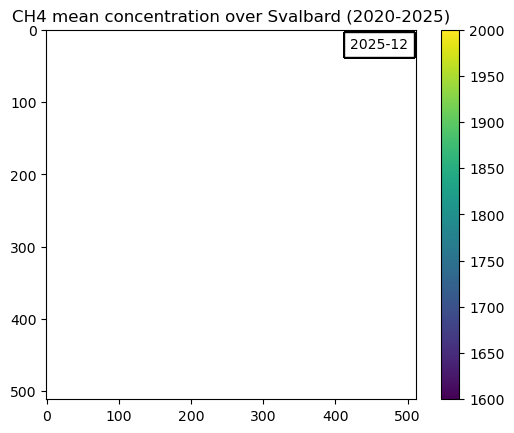

In [36]:
import os
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from osgeo import gdal
import geopandas as gpd
import pandas as pd
import rasterio
import numpy as np
# import cartopy.crs as ccrs

def rasterio_read(filename):
    with rasterio.open(filename) as raster:
        return raster

def read_geotiff(filename):
    ds = gdal.Open(filename)
    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray()
    return arr, ds

def show_plot(arr, title=""):
    plt.imshow(arr)
    plt.title(title)
    plt.colorbar()
    plt.show()

def load_images_from_folder(folder):
    images = []
    file_list = sorted(os.listdir(folder))
    for filename in file_list:
        img_path = os.path.join(folder, filename)
        img, _ = read_geotiff(img_path)
        # img = rasterio_read(img_path)
        if img is not None:
            images.append(img)
    return images


def leading_zero(n):
    return f"0{n}" if n < 10 else f"{n}"


def get_month(st_y, st_m, frame):
    # print(frame)
    m = 12 if (st_m + frame) % 12 == 0 else (st_m + frame) % 12
    y = (st_y) + (st_m + frame - 1) // 12
    return f"{y}-{leading_zero(m)}"

def convert_img(image):
    image = (image*400) + 1600

def mean_img(image):
    image = (image*400) + 1600
    mean = np.nanmean(image)
    return mean

concentration = []
def create_animation(images, interval=100):
    fig, ax = plt.subplots()
    # location_name = "Tokyo"
    location_name = "Svalbard"
    """
    crs = ccrs.epsg("3857")
    #fig, ax = plt.subplots(subplot_kw={"projection": crs})
    
    coords = [9.0, 76.0, 33.6, 81.0] #Svalbard
    countries = (
        #gpd.read_file("./data/countries_outline/ne_50m_admin_0_countries.shp")
        gpd.read_file("./data/countries_outline/SJM_adm0.shp")
        #.to_crs(3857)
        #.cx[76.0 : 81.0, 9.0 : 33.6]
        .reset_index(drop=True)
    )
    #ax.set_xlim([coords[0], coords[2]])
    #ax.set_ylim([coords[1], coords[3]])
    countries = countries[["NAME_ISO", "geometry"]]
    print(countries)"""
    img_display = ax.imshow(images[0], vmin=1600, vmax=2000)
    # countries.plot(ax=ax, facecolor="none", edgecolor="black")
    plt.title(f"CH4 mean concentration over {location_name} (2020-2025)")
    fig.colorbar(img_display)
    # concentration.append(mean_img(images[0]))
                    
    def update(frame):
        img_display.set_array(images[frame])
        print(f"{get_month(2020, 1, frame)}: {mean_img(images[frame])}")
        concentration.append(mean_img(images[frame]))
        ax.text(420, 25, get_month(2020, 1, frame), bbox=dict(facecolor="white"))
        #ax.text(420, 25, get_month(2022, 1, frame), bbox=dict(facecolor="white"))
        return img_display
    
    ani = animation.FuncAnimation(fig, update, frames=len(images), interval=interval, blit=False)
    # plt.show()
    ani.save(f"./data/export/2016_2025_{location_name}_mean.gif")
    #ani.save("./data/export/2022_2025_Svalbard_mean.gif")
    return ani

if __name__ == "__main__":
    folder_path = "./data/output_copernicus_mean_2/Svalbard"
    # folder_path = "./data/output_copernicus_mean/Tokyo"
    images = load_images_from_folder(folder_path)
    if images:
        create_animation(images, interval=100)


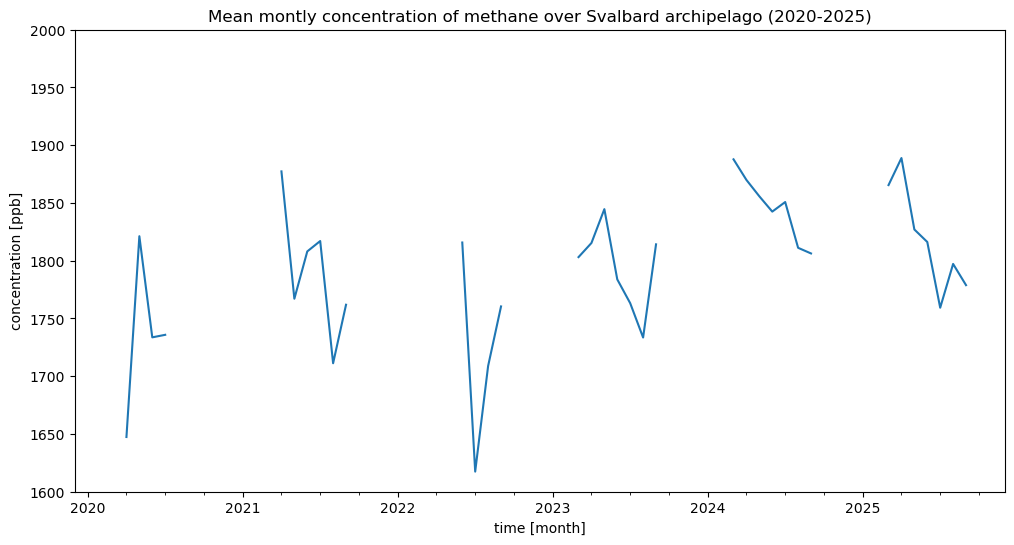

In [46]:
df = pd.DataFrame(concentration, index=pd.date_range(start='12/1/2019', periods=len(concentration), freq="ME"))
title = "Mean montly concentration of methane over Svalbard archipelago (2020-2025)"
xlabel = "time [month]"
ylabel = "concentration [ppb]"
ax = df.plot(title=title, xlabel=xlabel, ylabel=ylabel, ylim=(1600, 2000), figsize=(12,6), legend=None)
fig = ax.get_figure()
fig.savefig("./data/Svalbard_mean_CH4_concentration_2020-2025.png")